# Contribución acumulada de cabezas a la clasificación (2026-08-22)

**Esto no es ablación** (esa quedó en `notebooks/22082026_ablation/`, donde apagamos una cabeza a la vez dejando las demás intactas). Esto es distinto: **conectar la capa de clasificación a un subconjunto creciente de cabezas** de un mismo bloque — cabeza 1 sola, luego cabeza 1+2, luego 1+2+3, luego las 4 — y ver cómo se arma la predicción a medida que se van sumando.

En el `for` sobre las cabezas, en vez de "apagar una", vamos "guardando" las primeras `k` y saltando (poniendo en cero) el resto: con `k=1` saltamos las últimas 3 cabezas, con `k=2` saltamos las últimas 2, con `k=3` saltamos la última, con `k=4` no saltamos ninguna (eso último debe ser idéntico al forward normal — es el sanity check de siempre).

Por defecto lo hacemos sobre el **último bloque** (el que conecta directo con la capa de clasificación — `self.classifier(encoder_output[:, 0, :])`), que es lo que describiste. El resto del bloque (el MLP) sigue corriendo normal — solo se recorta cuántas cabezas de atención participan.

In [8]:
import json
import sys
from pathlib import Path

# Misma convención que el resto de notebooks/: vive 2 niveles bajo la raíz del proyecto.
project_root = Path.cwd().resolve().parents[1]
print(f"Project root: {project_root}")
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision

from modules.model import ViTForClassfication
from modules.datasets import CIFAR10Dataset

torch.manual_seed(0)

Project root: /Users/valefeve/Projects/interpretability of neural networks/interpretable-transformers


## 1. Cargar el modelo baseline

Mismo checkpoint que en los otros dos notebooks (`logit_lens.ipynb`, `ablation.ipynb`): `vit-with-15-epochs-CIFAR10`, para que los tres sean comparables entre sí. `map_location="cpu"` porque el checkpoint se guardó desde MPS. Igual que en `ablation.ipynb`, esto asume `use_faster_attention=False` (cabezas como submódulos separados).

In [9]:
EXPERIMENT_NAME = "vit-with-15-epochs-CIFAR10"
exp_dir = project_root / "experimentation" / "experiments" / EXPERIMENT_NAME

with open(exp_dir / "config.json") as f:
    config = json.load(f)
with open(exp_dir / "metrics.json") as f:
    metrics = json.load(f)

assert not config["use_faster_attention"], (
    "Este notebook asume block.attention.heads (cabezas separadas); "
    "con use_faster_attention=True habria que adaptar la funcion de abajo."
)

model = ViTForClassfication(config)
state_dict = torch.load(exp_dir / "model_final.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()

n_blocks = len(model.encoder.blocks)
n_heads = config["num_attention_heads"]
print(f"Checkpoint: {EXPERIMENT_NAME}  (accuracy de entrenamiento: {metrics['accuracy']:.4f})")
print(f"Bloques: {n_blocks}  |  cabezas por bloque: {n_heads}")

Checkpoint: vit-with-15-epochs-CIFAR10  (accuracy de entrenamiento: 0.6023)
Bloques: 4  |  cabezas por bloque: 4


## 2. Datos de test (CIFAR-10)

Mismo patrón que en los otros dos notebooks: apuntamos a `experimentation/data`, donde ya está descargado CIFAR-10.

In [10]:
dataset = CIFAR10Dataset()
dataset.testset = torchvision.datasets.CIFAR10(
    root=str(project_root / "experimentation" / "data"),
    train=False,
    download=True,
    transform=dataset.test_transform,
)
classes = dataset.classes

N_EVAL = 500  # tamano del lote de evaluacion (CPU-friendly)
eval_images, eval_labels = dataset.get_samples_from_indices(range(N_EVAL), device="cpu", set="test")
print(f"Lote de evaluacion: {N_EVAL} imagenes de test")

Lote de evaluacion: 500 imagenes de test


## 3. La función: cabezas acumuladas dentro de un bloque

`forward_with_heads_kept(model, x, target_layer_idx, n_heads_kept)`: en el bloque `target_layer_idx`, corre cada cabeza por separado (como hace `MultiHeadAttention.forward` internamente) pero solo deja activas las primeras `n_heads_kept` (índices `0..n_heads_kept-1`); el resto se pone en cero antes de concatenar y proyectar. El MLP de ese bloque y todos los bloques siguientes (si los hay) corren normal. Con `n_heads_kept = n_heads` nada se toca — debe reproducir el forward normal exacto.

In [11]:
@torch.no_grad()
def forward_with_heads_kept(model, x, target_layer_idx, n_heads_kept):
    h = model.embedding(x)
    for i, block in enumerate(model.encoder.blocks):
        if i == target_layer_idx:
            attn_in = block.layernorm_1(h)
            head_outputs = []
            for hidx, head in enumerate(block.attention.heads):
                out, _ = head(attn_in)
                if hidx >= n_heads_kept:
                    out = torch.zeros_like(out)
                head_outputs.append(out)
            concat = torch.cat(head_outputs, dim=-1)
            attn_out = block.attention.output_projection(concat)
            attn_out = block.attention.output_dropout(attn_out)
            h = h + attn_out
            mlp_out = block.mlp(block.layernorm_2(h))
            h = h + mlp_out
        else:
            h, _ = block(h, output_attentions=False)
    return model.classifier(h[:, 0, :])


@torch.no_grad()
def accuracy_of(logits, labels):
    return (logits.argmax(dim=-1) == labels).float().mean().item()

In [12]:
# Sanity check: con n_heads_kept = n_heads (todas activas), debe coincidir
# EXACTAMENTE con el forward normal del modelo, para cualquier bloque.
with torch.no_grad():
    direct_logits, _ = model(eval_images, output_attentions=False)

for layer_idx in range(n_blocks):
    test_logits = forward_with_heads_kept(model, eval_images, target_layer_idx=layer_idx, n_heads_kept=n_heads)
    diff = (direct_logits - test_logits).abs().max().item()
    assert diff < 1e-5, f"block {layer_idx}: deberia coincidir con el forward normal (diff={diff})"

baseline_accuracy = accuracy_of(direct_logits, eval_labels)
print(f"Accuracy baseline (sin recortar cabezas, n={N_EVAL}): {baseline_accuracy:.3f}")
print("OK - con todas las cabezas activas, la funcion reproduce el forward normal en cualquier bloque.")

Accuracy baseline (sin recortar cabezas, n=500): 0.578
OK - con todas las cabezas activas, la funcion reproduce el forward normal en cualquier bloque.


## 4. Cómo se arma la predicción, cabeza por cabeza (último bloque)

`TARGET_LAYER_IDX` está fijo en el último bloque (el que conecta directo con la capa de clasificación). `k=1` = solo cabeza 1 (saltamos las últimas 3), `k=2` = cabeza 1+2 (saltamos las últimas 2), `k=3` = cabeza 1+2+3 (saltamos la última), `k=4` = las 4 (baseline).

k=0: accuracy = 0.526  -- ninguna cabeza activa
k=1: accuracy = 0.536  -- cabezas 1..1 activas (saltamos las ultimas 3)
k=2: accuracy = 0.570  -- cabezas 1..2 activas (saltamos las ultimas 2)
k=3: accuracy = 0.556  -- cabezas 1..3 activas (saltamos la ultima)
k=4: accuracy = 0.578  -- las 4 cabezas activas (= baseline)


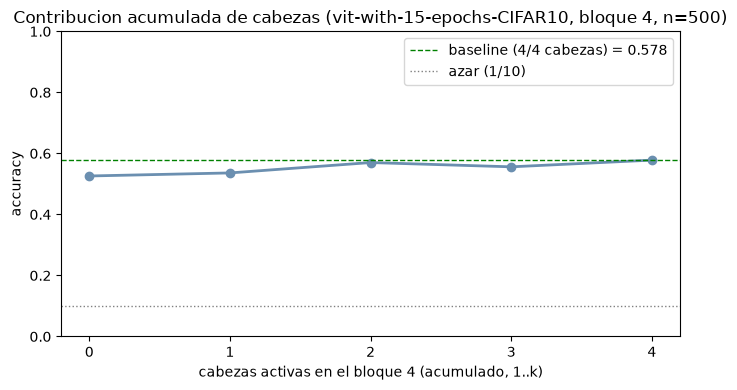

In [13]:
TARGET_LAYER_IDX = n_blocks - 1  # ultimo bloque; cambialo si quieres ver otro

cumulative_accuracies = []
for k in range(0, n_heads + 1):
    logits = forward_with_heads_kept(model, eval_images, target_layer_idx=TARGET_LAYER_IDX, n_heads_kept=k)
    acc = accuracy_of(logits, eval_labels)
    cumulative_accuracies.append(acc)
    skipped = n_heads - k
    if k == 0:
        label = "ninguna cabeza activa"
    elif skipped == 0:
        label = "las 4 cabezas activas (= baseline)"
    elif skipped == 1:
        label = f"cabezas 1..{k} activas (saltamos la ultima)"
    else:
        label = f"cabezas 1..{k} activas (saltamos las ultimas {skipped})"
    print(f"k={k}: accuracy = {acc:.3f}  -- {label}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(0, n_heads + 1), cumulative_accuracies, marker="o", linewidth=2, color="#6b8fb0")
ax.axhline(baseline_accuracy, color="green", linestyle="--", linewidth=1, label=f"baseline (4/4 cabezas) = {baseline_accuracy:.3f}")
ax.axhline(1 / len(classes), color="gray", linestyle=":", linewidth=1, label="azar (1/10)")
ax.set_xticks(range(0, n_heads + 1))
ax.set_xlabel(f"cabezas activas en el bloque {TARGET_LAYER_IDX + 1} (acumulado, 1..k)")
ax.set_ylabel("accuracy")
ax.set_title(f"Contribucion acumulada de cabezas ({EXPERIMENT_NAME}, bloque {TARGET_LAYER_IDX + 1}, n={N_EVAL})")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Extra: lo mismo, pero en cada bloque

La misma función, generalizada a los 4 bloques — no solo el último. Un heatmap (bloque × cuántas cabezas activas) muestra si el patrón "se arma con pocas cabezas" es igual en todos los bloques o solo pasa en algunos.

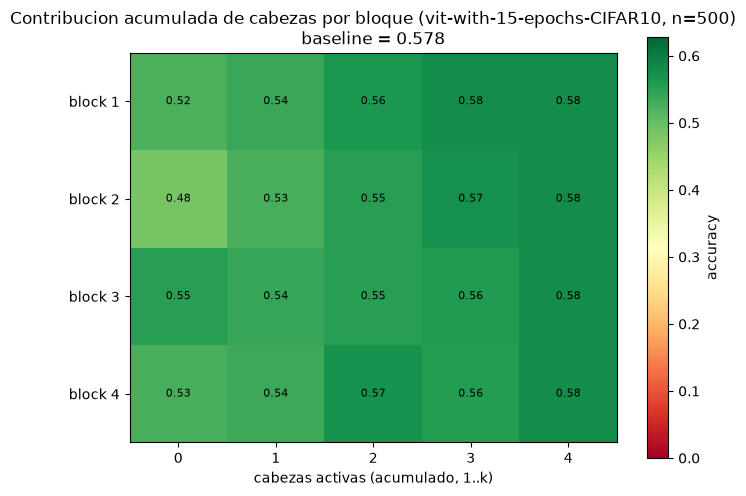

In [14]:
grid_accuracy = np.zeros((n_blocks, n_heads + 1))
for layer_idx in range(n_blocks):
    for k in range(0, n_heads + 1):
        logits = forward_with_heads_kept(model, eval_images, target_layer_idx=layer_idx, n_heads_kept=k)
        grid_accuracy[layer_idx, k] = accuracy_of(logits, eval_labels)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(grid_accuracy, cmap="RdYlGn", vmin=0, vmax=baseline_accuracy + 0.05)
ax.set_xticks(range(n_heads + 1))
ax.set_xticklabels([str(k) for k in range(n_heads + 1)])
ax.set_yticks(range(n_blocks))
ax.set_yticklabels([f"block {l+1}" for l in range(n_blocks)])
for l in range(n_blocks):
    for k in range(n_heads + 1):
        ax.text(k, l, f"{grid_accuracy[l, k]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xlabel("cabezas activas (acumulado, 1..k)")
ax.set_title(f"Contribucion acumulada de cabezas por bloque ({EXPERIMENT_NAME}, n={N_EVAL})\nbaseline = {baseline_accuracy:.3f}")
fig.colorbar(im, ax=ax, label="accuracy")
plt.tight_layout()
plt.show()

## Para reflexionar / siguientes pasos

- En el último bloque, ¿con cuántas cabezas activas ya se acerca a la accuracy baseline? Si con 1-2 cabezas ya casi se llega, esas cabezas concentran la señal que importa para clasificar; si hace falta llegar a 4, la decisión está más repartida.
- ¿El orden 1→2→3→4 importa? Esto suma las cabezas en un orden fijo (1, luego 2, luego 3...) — no es lo mismo que probar todos los órdenes posibles (eso sería un análisis tipo Shapley, más caro). Si el resultado te sorprende, vale la pena probar otro orden (por ejemplo, empezando por la cabeza que salió más crítica en `ablation.ipynb`) para ver si el orden cambia la conclusión.
- Comparar esta misma curva/heatmap contra el checkpoint `interpretable` es el paralelo directo de lo que ya se propuso para `ablation.ipynb`: ¿la penalización hace que la curva suba más despacio (cada cabeza aporta un poco) o igual de rápido (unas pocas cabezas siguen dominando)?